In [1]:
%load_ext autoreload
%autoreload 2

from pre import *

root = r"D:\Faculty\ML-Dr-Ayman\Project-Dr\10000"
x_img, x_flat, y = load_dataset_from_folders(
    root_dir=root,
    size=(28, 28),
    normalize=True
)
print(f"image shape: {x_img.shape} flat shape: {x_flat.shape} labels shape: {y.shape}")

Loading image: D:\Faculty\ML-Dr-Ayman\Project-Dr\10000\0\0_1.jpg, original size: (33, 29), mode: RGB
Processed image :D:\Faculty\ML-Dr-Ayman\Project-Dr\10000\0\0_1.jpg , resized : (28, 28), mode: L
Loading image: D:\Faculty\ML-Dr-Ayman\Project-Dr\10000\0\0_10.jpg, original size: (25, 27), mode: RGB
Processed image :D:\Faculty\ML-Dr-Ayman\Project-Dr\10000\0\0_10.jpg , resized : (28, 28), mode: L
Loading image: D:\Faculty\ML-Dr-Ayman\Project-Dr\10000\0\0_100.jpg, original size: (35, 35), mode: RGB
Processed image :D:\Faculty\ML-Dr-Ayman\Project-Dr\10000\0\0_100.jpg , resized : (28, 28), mode: L
Loading image: D:\Faculty\ML-Dr-Ayman\Project-Dr\10000\0\0_1000.jpg, original size: (24, 28), mode: RGB
Processed image :D:\Faculty\ML-Dr-Ayman\Project-Dr\10000\0\0_1000.jpg , resized : (28, 28), mode: L
Loading image: D:\Faculty\ML-Dr-Ayman\Project-Dr\10000\0\0_101.jpg, original size: (56, 78), mode: RGB
Processed image :D:\Faculty\ML-Dr-Ayman\Project-Dr\10000\0\0_101.jpg , resized : (28, 28), mo

In [2]:
x_flat

array([[0.627451  , 0.65882355, 0.654902  , ..., 0.6392157 , 0.6       ,
        0.63529414],
       [0.54509807, 0.47843137, 0.24705882, ..., 0.6784314 , 0.65882355,
        0.6745098 ],
       [0.6862745 , 0.68235296, 0.6745098 , ..., 0.47843137, 0.5882353 ,
        0.6117647 ],
       ...,
       [0.7019608 , 0.6862745 , 0.6862745 , ..., 0.6627451 , 0.7490196 ,
        0.52156866],
       [0.6784314 , 0.6784314 , 0.68235296, ..., 0.6313726 , 0.67058825,
        0.70980394],
       [0.74509805, 0.67058825, 0.6901961 , ..., 0.21960784, 0.26666668,
        0.23921569]], dtype=float32)

In [3]:
from sklearn.model_selection import train_test_split
import numpy as np
xf_train, xf_test, y_train, y_test = train_test_split(
    x_flat, y, test_size=0.2, random_state=42 ,stratify=y
)
xi_train, xi_test, y_train, y_test = train_test_split(
    x_img, y, test_size=0.2, random_state=42 ,stratify=y
)
np.save("processed-imgs/xf_train.npy", xf_train)
np.save("processed-imgs/xf_test.npy", xf_test)
np.save("processed-imgs/y_train.npy", y_train) 
np.save("processed-imgs/y_test.npy", y_test)
np.save("processed-imgs/xi_train.npy", xi_train)
np.save("processed-imgs/xi_test.npy", xi_test)

In [4]:
xf_train

array([[0.68235296, 0.6784314 , 0.6784314 , ..., 0.6745098 , 0.6784314 ,
        0.6745098 ],
       [0.61960787, 0.6431373 , 0.654902  , ..., 0.60784316, 0.6039216 ,
        0.6       ],
       [0.6156863 , 0.6431373 , 0.6117647 , ..., 0.38039216, 0.43137255,
        0.5568628 ],
       ...,
       [0.54901963, 0.54901963, 0.5294118 , ..., 0.6862745 , 0.69803923,
        0.7019608 ],
       [0.2901961 , 0.32941177, 0.36078432, ..., 0.29803923, 0.43529412,
        0.64705884],
       [0.7647059 , 0.77254903, 0.78039217, ..., 0.7490196 , 0.74509805,
        0.74509805]], dtype=float32)

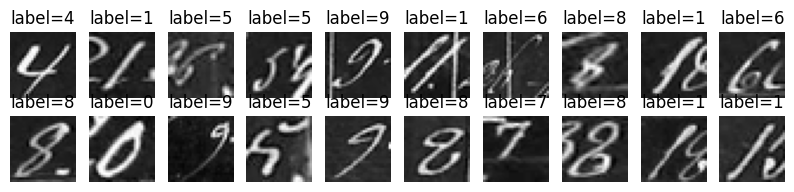

In [5]:
from plot_sample import plot_sample
plot_sample(xi_train, y_train)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(xf_train)
x_test_scaled = scaler.transform(xf_test)
np.save("processed-imgs/xf_train_scaled.npy", x_train_scaled)
np.save("processed-imgs/xf_test_scaled.npy", x_test_scaled) 


In [8]:
x_test_scaled

array([[ 0.18859038,  0.07148069, -0.01496025, ..., -0.10354358,
         0.10035497,  0.15294625],
       [ 1.601683  ,  1.7030908 ,  1.5977302 , ...,  1.530407  ,
         1.5569541 ,  1.5192829 ],
       [-4.116413  , -4.82335   , -4.544219  , ..., -1.032653  ,
        -0.9762621 , -0.9097603 ],
       ...,
       [ 1.2730569 ,  0.9892614 ,  1.0487291 , ..., -2.6986418 ,
        -3.002835  , -2.0635557 ],
       [ 1.0758811 ,  1.0572451 ,  1.0487291 , ...,  0.9857568 ,
         1.4619586 ,  0.760207  ],
       [ 0.0571399 ,  0.07148069,  0.05366487, ...,  0.05664766,
         0.03702457,  0.03149409]], dtype=float32)

In [9]:
from sklearn.linear_model import LinearRegression
mlr_model = LinearRegression()

In [ ]:
from sklearn.model_selection import cross_val_score , cross_validate
from time import time

In [12]:
start = time()
kf_scores=cross_validate(mlr_model, xf_train, y_train, cv=5, scoring='r2',return_train_score=True)
time_mlr_kf = time() - start
print(f"KFold Cross-validation time: {time_mlr_kf:.2f} seconds")
print(f"KFold Cross-validation train R2 scores: {kf_scores['train_score']}")
print(f"KFold Cross-validation test R2 scores: {kf_scores['test_score']}")




KFold Cross-validation time: 5.19 seconds
KFold Cross-validation train R2 scores: [0.40252632 0.38237995 0.39769775 0.40313637 0.39185286]
KFold Cross-validation test R2 scores: [0.17797226 0.28141212 0.19199842 0.19904083 0.22980291]


In [14]:
avg_kf_score_train = kf_scores['train_score'].mean()
print(f"Average KFold Cross-validation train R2 score: {avg_kf_score_train}")   
std_kf_score_train = kf_scores['train_score'].std()
print(f"Standard Deviation of KFold Cross-validation train R2 scores: {std_kf_score_train}")

avg_kf_score_test = kf_scores['test_score'].mean()
print(f"Average KFold Cross-validation test R2 score: {avg_kf_score_test}")   
std_kf_score_test = kf_scores['test_score'].std()
print(f"Standard Deviation of KFold Cross-validation test R2 scores: {std_kf_score_test}")

Average KFold Cross-validation train R2 score: 0.39551864862442015
Standard Deviation of KFold Cross-validation train R2 scores: 0.007719444208690398
Average KFold Cross-validation test R2 score: 0.21604530811309813
Standard Deviation of KFold Cross-validation test R2 scores: 0.03682133735325864


In [17]:
start = time()
mlr_model.fit(xf_train, y_train)
time_mlr_kf += time() - start 

In [18]:
print (f"Rsquared on train : {mlr_model.score(xf_train, y_train)}")
print (f"Rsquared on test : {mlr_model.score(xf_test, y_test)}")

Rsquared on train : 0.37951284646987915
Rsquared on test : 0.21417123079299927


In [ ]:
y_train_pred = mlr_model.predict(xf_train)
y_test_pred = mlr_model.predict(xf_test)


In [20]:
y_train_pred

array([6.689351 , 3.1532443, 3.6422956, ..., 4.8237615, 3.9018884,
       5.078153 ], dtype=float32)

optional calculate errore

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)   
print(f"Mean Absolute Error on test: {mae_test}")
print(f"Mean Squared Error on test: {mse_test}")
rmse_test = np.sqrt(mse_test)
print(f"Root Mean Squared Error on test: {rmse_test}")

Mean Absolute Error on test: 2.086880922317505
Mean Squared Error on test: 6.483087539672852
Root Mean Squared Error on test: 2.5461907901162575


In [22]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"Mean Absolute Error on train: {mae_train}")
print(f"Mean Squared Error on train: {mse_train}")  
rmse_train = np.sqrt(mse_train)
print(f"Root Mean Squared Error on train: {rmse_train}")    

Mean Absolute Error on train: 1.8776426315307617
Mean Squared Error on train: 5.119019031524658
Root Mean Squared Error on train: 2.2625249239565646


rounding to get the discrete class labels

In [23]:
from rounding import round_regression_to_classification
y_test_pred_round = round_regression_to_classification(y_test_pred)
y_test_pred_round

array([7, 6, 2, ..., 0, 4, 9])

In [24]:
from cmetrics import *
accuracy_mlr = acc(y_test, y_test_pred_round)
print(f"Accuracy after rounding: {accuracy_mlr:.4f}%")
prec_mlr = precision(y_test, y_test_pred_round)
print(f"Precision after rounding: {prec_mlr:.4f}%")
rec_mlr = recall(y_test, y_test_pred_round)
print(f"Recall after rounding: {rec_mlr:.4f}%")  
f1_score_mlr =f1(y_test, y_test_pred_round)
print(f"F1 Score after rounding: {f1_score_mlr:.4f}%")

Accuracy after rounding: 13.5000%
Precision after rounding: 18.0781%
Recall after rounding: 13.5000%
F1 Score after rounding: 12.4851%


actially very bad ---> just predicting continuous numbers 

In [ ]:
import json

metrics = {
    "accuracy": accuracy_mlr,
    "precision": prec_mlr,
    "recall": rec_mlr,
    "f1_score": f1_score_mlr,
    "train_time": time_mlr_kf
}

with open("experiments/mlr.json", "w") as f:
    json.dump(metrics, f, indent=4)


In [26]:
cm=conf_matrix(y_test, y_test_pred_round)
cm

array([[12, 25, 34, 56, 43, 18,  8,  3,  0,  1],
       [ 5,  4, 25, 48, 72, 31, 13,  1,  1,  0],
       [ 5,  8, 23, 46, 67, 30, 16,  2,  1,  2],
       [ 1, 12, 28, 40, 54, 35, 20,  6,  3,  1],
       [ 0,  2, 15, 27, 62, 54, 25, 11,  3,  1],
       [ 0,  2,  5, 20, 54, 46, 44, 17,  7,  5],
       [ 4,  8, 12, 27, 56, 54, 26,  7,  4,  2],
       [ 1,  1,  0,  7, 24, 65, 55, 31, 11,  5],
       [ 0,  3,  3,  7, 37, 43, 56, 22, 16, 13],
       [ 1,  2,  1,  9, 36, 44, 43, 32, 22, 10]], dtype=int64)

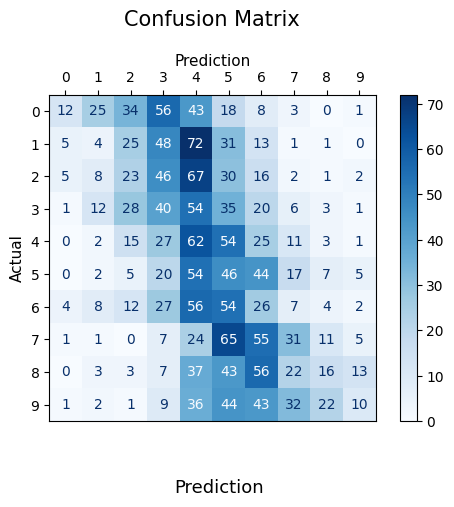

In [27]:
plot_confusion_matrix(cm)